In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Imports ready.')

Imports ready.


In [3]:
DATASETS = {
    'CIFAR-10': '/content/drive/MyDrive/xai-stability-benchmark/results_cifar10',
    'ImageNet': '/content/drive/MyDrive/xai-stability-benchmark/results_imagenet_',
    'COCO':     '/content/drive/MyDrive/xai-stability-benchmark/results_coco',
}

TOTAL_IMAGES = {
    'CIFAR-10': 10000,
    'ImageNet': 40000,
    'COCO':     30000,
}

MODEL_NAMES = ['resnet50', 'densenet121', 'convnext_tiny', 'vit_b_16']
MODEL_DISPLAY = {
    'resnet50': 'ResNet-50',
    'densenet121': 'DenseNet-121',
    'convnext_tiny': 'ConvNeXt-T',
    'vit_b_16': 'ViT-B/16',
}
PERTURBATIONS = ['rotation', 'translation', 'brightness', 'noise', 'jpeg']
PERT_DISPLAY = {
    'rotation': 'Rotation',
    'translation': 'Translation',
    'brightness': 'Brightness',
    'noise': 'Noise',
    'jpeg': 'JPEG',
}
XAI_METHODS = ['ig_fass', 'shap_fass', 'gradcam_fass', 'lime_fass']
XAI_DISPLAY = {
    'ig_fass': 'IG',
    'shap_fass': 'GradSHAP',
    'gradcam_fass': 'Grad-CAM',
    'lime_fass': 'LIME',
}
XAI_COLORS = {
    'IG': '#2196F3',
    'GradSHAP': '#FF9800',
    'Grad-CAM': '#4CAF50',
    'LIME': '#E91E63',
}
DATASET_COLORS = {
    'CIFAR-10': '#7B1FA2',
    'ImageNet': '#1565C0',
    'COCO': '#2E7D32',
}

FIG_DIR = '/content/drive/MyDrive/xai-stability-benchmark/paper_figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('Configuration set.')
for ds, path in DATASETS.items():
    exists = os.path.isdir(path)
    n_files = len(glob.glob(os.path.join(path, '*.csv'))) if exists else 0
    print(f'  {ds}: {"FOUND" if exists else "MISSING"} ({n_files} CSVs)')

Configuration set.
  CIFAR-10: FOUND (42 CSVs)
  ImageNet: FOUND (32 CSVs)
  COCO: FOUND (42 CSVs)


In [4]:
def load_dataset_results(ds_name, result_dir):
    rows = []
    total_images = TOTAL_IMAGES.get(ds_name, None)

    for model in MODEL_NAMES:
        for pert in PERTURBATIONS:
            row = {'dataset': ds_name, 'model': model, 'perturbation': pert}

            fast_path = os.path.join(result_dir, f'{model}_fass_{pert}.csv')
            if os.path.exists(fast_path):
                df_fast = pd.read_csv(fast_path)
                row['n_retained'] = len(df_fast)
                if total_images:
                    row['retention_pct'] = len(df_fast) / total_images * 100
                for col in ['ig_fass', 'shap_fass', 'gradcam_fass']:
                    if col in df_fast.columns:
                        row[col] = df_fast[col].mean()
                        row[col.replace('_fass', '_std')] = df_fast[col].std()
                if 'lime_fass' in df_fast.columns:
                    row['lime_fass'] = df_fast['lime_fass'].mean()
                    row['lime_std'] = df_fast['lime_fass'].std()

            lime_path = os.path.join(result_dir, f'{model}_fass_lime_{pert}.csv')
            if os.path.exists(lime_path) and 'lime_fass' not in row:
                df_lime = pd.read_csv(lime_path)
                if 'lime_fass' in df_lime.columns:
                    row['lime_fass'] = df_lime['lime_fass'].mean()
                    row['lime_std'] = df_lime['lime_fass'].std()
                if 'n_retained' not in row:
                    row['n_retained'] = len(df_lime)
                    if total_images:
                        row['retention_pct'] = len(df_lime) / total_images * 100

            rows.append(row)

    return pd.DataFrame(rows)

all_results = []
for ds_name, result_dir in DATASETS.items():
    if os.path.isdir(result_dir):
        df = load_dataset_results(ds_name, result_dir)
        all_results.append(df)
        print(f'\n{ds_name}: loaded {len(df)} conditions')
        for method in XAI_METHODS:
            n_filled = df[method].notna().sum() if method in df.columns else 0
            print(f'  {XAI_DISPLAY[method]:>10s}: {n_filled}/{len(df)} conditions have data')
    else:
        print(f'\n{ds_name}: directory not found, skipping.')

results = pd.concat(all_results, ignore_index=True)
print(f'\nTotal: {len(results)} conditions across {results["dataset"].nunique()} datasets')


CIFAR-10: loaded 20 conditions
          IG: 20/20 conditions have data
    GradSHAP: 20/20 conditions have data
    Grad-CAM: 20/20 conditions have data
        LIME: 20/20 conditions have data

ImageNet: loaded 20 conditions
          IG: 12/20 conditions have data
    GradSHAP: 12/20 conditions have data
    Grad-CAM: 12/20 conditions have data
        LIME: 20/20 conditions have data

COCO: loaded 20 conditions
          IG: 20/20 conditions have data
    GradSHAP: 20/20 conditions have data
    Grad-CAM: 20/20 conditions have data
        LIME: 20/20 conditions have data

Total: 60 conditions across 3 datasets


In [5]:
print('=' * 80)
print('FULL DATA MATRIX')
print('=' * 80)

for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]
    print(f'\n--- {ds} ---')
    for model in MODEL_NAMES:
        m_df = ds_df[ds_df['model'] == model]
        print(f'\n  {MODEL_DISPLAY[model]}:')
        for _, r in m_df.iterrows():
            pert = r['perturbation']
            ret = f"{r.get('retention_pct', 0):.1f}%" if pd.notna(r.get('retention_pct')) else '---'
            ig = f"{r['ig_fass']:.3f}" if pd.notna(r.get('ig_fass')) else ' --- '
            sh = f"{r['shap_fass']:.3f}" if pd.notna(r.get('shap_fass')) else ' --- '
            gc = f"{r['gradcam_fass']:.3f}" if pd.notna(r.get('gradcam_fass')) else ' --- '
            lm = f"{r['lime_fass']:.3f}" if pd.notna(r.get('lime_fass')) else ' --- '
            print(f'    {pert:12s}  ret={ret:>6s}  IG={ig}  SHAP={sh}  GradCAM={gc}  LIME={lm}')

FULL DATA MATRIX

--- CIFAR-10 ---

  ResNet-50:
    rotation      ret= 37.2%  IG=0.422  SHAP=0.423  GradCAM=0.450  LIME=0.282
    translation   ret=  0.6%  IG=0.560  SHAP=0.501  GradCAM=0.529  LIME=0.346
    brightness    ret=  9.0%  IG=0.470  SHAP=0.425  GradCAM=0.643  LIME=0.346
    noise         ret= 26.9%  IG=0.381  SHAP=0.393  GradCAM=0.449  LIME=0.284
    jpeg          ret=  0.1%  IG=0.528  SHAP=0.468  GradCAM=0.703  LIME=0.350

  DenseNet-121:
    rotation      ret= 20.8%  IG=0.446  SHAP=0.445  GradCAM=0.535  LIME=0.279
    translation   ret=  0.1%  IG=0.532  SHAP=0.491  GradCAM=0.523  LIME=0.339
    brightness    ret=  0.1%  IG=0.511  SHAP=0.479  GradCAM=0.735  LIME=0.338
    noise         ret= 12.1%  IG=0.380  SHAP=0.384  GradCAM=0.553  LIME=0.273
    jpeg          ret=  0.1%  IG=0.599  SHAP=0.520  GradCAM=0.760  LIME=0.344

  ConvNeXt-T:
    rotation      ret= 45.3%  IG=0.456  SHAP=0.457  GradCAM=0.548  LIME=0.295
    translation   ret=  0.1%  IG=0.581  SHAP=0.536  GradCAM=0

In [6]:
# Cell 5 — Retention Rate Summary

print('=' * 80)
print('RETENTION RATE SUMMARY')
print('=' * 80)

ret_data = results.dropna(subset=['retention_pct'])

if len(ret_data) > 0:
    global_min = ret_data['retention_pct'].min()
    global_max = ret_data['retention_pct'].max()
    print(f'\nGlobal range: {global_min:.1f}% - {global_max:.1f}%')

    print(f'\nBy perturbation type (mean +/- std across models & datasets):')
    for pert in PERTURBATIONS:
        p_data = ret_data[ret_data['perturbation'] == pert]['retention_pct']
        if len(p_data) > 0:
            print(f'  {PERT_DISPLAY[pert]:12s}: {p_data.mean():5.1f}% +/- {p_data.std():4.1f}%  '
                  f'(range: {p_data.min():.1f}% - {p_data.max():.1f}%)')

    print(f'\nBy dataset (mean across all conditions):')
    for ds in results['dataset'].unique():
        d_data = ret_data[ret_data['dataset'] == ds]['retention_pct']
        if len(d_data) > 0:
            print(f'  {ds:10s}: {d_data.mean():5.1f}% +/- {d_data.std():4.1f}%')

    pert_means = ret_data.groupby('perturbation')['retention_pct'].mean()
    print(f'\nLowest retention:  {PERT_DISPLAY[pert_means.idxmin()]} ({pert_means.min():.1f}%)')
    print(f'Highest retention: {PERT_DISPLAY[pert_means.idxmax()]} ({pert_means.max():.1f}%)')
else:
    print('No retention data available.')

RETENTION RATE SUMMARY

Global range: 0.0% - 104.4%

By perturbation type (mean +/- std across models & datasets):
  Rotation    :  30.9% +/- 27.5%  (range: 0.0% - 88.1%)
  Translation :   0.1% +/-  0.2%  (range: 0.0% - 0.6%)
  Brightness  :   0.8% +/-  2.6%  (range: 0.0% - 9.0%)
  Noise       :  34.5% +/- 38.7%  (range: 0.0% - 104.4%)
  JPEG        :   1.0% +/-  3.4%  (range: 0.0% - 11.7%)

By dataset (mean across all conditions):
  CIFAR-10  :  11.5% +/- 15.3%
  ImageNet  :   0.0% +/-  0.0%
  COCO      :  28.9% +/- 37.7%

Lowest retention:  Translation (0.1%)
Highest retention: Noise (34.5%)


In [7]:
# Cell 6 — Table 1: Per-Dataset FASS Tables (Model x XAI Method)
#
# Average FASS across ALL 5 perturbations per model per method.

def make_dataset_table(ds_name, ds_df):
    rows = []
    for model in MODEL_NAMES:
        m_df = ds_df[ds_df['model'] == model]
        row = {'Model': MODEL_DISPLAY[model]}
        for method in XAI_METHODS:
            vals = m_df[method].dropna()
            if len(vals) > 0:
                row[XAI_DISPLAY[method]] = vals.mean()
            else:
                row[XAI_DISPLAY[method]] = np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('Model')


print('=' * 80)
print('MAIN RESULT TABLES (averaged across all perturbations)')
print('=' * 80)

dataset_tables = {}
for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]
    tbl = make_dataset_table(ds, ds_df)
    dataset_tables[ds] = tbl

    print(f'\n--- {ds} ---')
    print(tbl.round(3).to_string())

    for model in tbl.index:
        best = tbl.loc[model].idxmax()
        val = tbl.loc[model].max()
        print(f'  Best for {model}: {best} ({val:.3f})')

MAIN RESULT TABLES (averaged across all perturbations)

--- CIFAR-10 ---
                 IG  GradSHAP  Grad-CAM   LIME
Model                                         
ResNet-50     0.472     0.442     0.555  0.322
DenseNet-121  0.494     0.464     0.621  0.315
ConvNeXt-T    0.547     0.516     0.719  0.333
ViT-B/16      0.534     0.507     0.654  0.346
  Best for ResNet-50: Grad-CAM (0.555)
  Best for DenseNet-121: Grad-CAM (0.621)
  Best for ConvNeXt-T: Grad-CAM (0.719)
  Best for ViT-B/16: Grad-CAM (0.654)

--- ImageNet ---
                 IG  GradSHAP  Grad-CAM   LIME
Model                                         
ResNet-50     0.487     0.462     0.782  0.408
DenseNet-121  0.482     0.456     0.822  0.416
ConvNeXt-T    0.505     0.486     0.824  0.416
ViT-B/16      0.530     0.495     0.802  0.450
  Best for ResNet-50: Grad-CAM (0.782)
  Best for DenseNet-121: Grad-CAM (0.822)
  Best for ConvNeXt-T: Grad-CAM (0.824)
  Best for ViT-B/16: Grad-CAM (0.802)

--- COCO ---
             

In [8]:
# Cell 7 — LaTeX Table Output

def to_latex_bold_max(tbl, caption, label):
    n_cols = len(tbl.columns)
    lines = []
    lines.append(r'\begin{table}[t]')
    lines.append(r'\centering')
    lines.append(r'\caption{' + caption + '}')
    lines.append(r'\label{' + label + '}')
    lines.append(r'\begin{tabular}{l' + 'c' * n_cols + '}')
    lines.append(r'\toprule')
    header = 'Model & ' + ' & '.join(tbl.columns) + r' \\'
    lines.append(header)
    lines.append(r'\midrule')
    for model in tbl.index:
        row_vals = tbl.loc[model]
        max_val = row_vals.max()
        cells = []
        for v in row_vals:
            if pd.isna(v):
                cells.append('---')
            elif v == max_val:
                cells.append(r'\textbf{' + f'{v:.3f}' + '}')
            else:
                cells.append(f'{v:.3f}')
        lines.append(model + ' & ' + ' & '.join(cells) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)


print('=' * 80)
print('LATEX TABLES')
print('=' * 80)

for ds, tbl in dataset_tables.items():
    ds_lower = ds.lower().replace('-', '')
    latex = to_latex_bold_max(
        tbl,
        caption=f'FASS scores on {ds} averaged across all perturbation types. Bold indicates the most stable method per architecture.',
        label=f'tab:fass_{ds_lower}'
    )
    print(f'\n% === {ds} ===')
    print(latex)
    print()

LATEX TABLES

% === CIFAR-10 ===
\begin{table}[t]
\centering
\caption{FASS scores on CIFAR-10 averaged across all perturbation types. Bold indicates the most stable method per architecture.}
\label{tab:fass_cifar10}
\begin{tabular}{lcccc}
\toprule
Model & IG & GradSHAP & Grad-CAM & LIME \\
\midrule
ResNet-50 & 0.472 & 0.442 & \textbf{0.555} & 0.322 \\
DenseNet-121 & 0.494 & 0.464 & \textbf{0.621} & 0.315 \\
ConvNeXt-T & 0.547 & 0.516 & \textbf{0.719} & 0.333 \\
ViT-B/16 & 0.534 & 0.507 & \textbf{0.654} & 0.346 \\
\bottomrule
\end{tabular}
\end{table}


% === ImageNet ===
\begin{table}[t]
\centering
\caption{FASS scores on ImageNet averaged across all perturbation types. Bold indicates the most stable method per architecture.}
\label{tab:fass_imagenet}
\begin{tabular}{lcccc}
\toprule
Model & IG & GradSHAP & Grad-CAM & LIME \\
\midrule
ResNet-50 & 0.487 & 0.462 & \textbf{0.782} & 0.408 \\
DenseNet-121 & 0.482 & 0.456 & \textbf{0.822} & 0.416 \\
ConvNeXt-T & 0.505 & 0.486 & \textbf{0.824}

In [9]:
# Cell 8 — Per-Perturbation Breakdown
#
# Shows which perturbation produces the most/least stable attributions.

print('=' * 80)
print('PER-PERTURBATION FASS BREAKDOWN')
print('=' * 80)

for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]
    print(f'\n--- {ds} ---')

    for method in XAI_METHODS:
        method_name = XAI_DISPLAY[method]
        pert_scores = {}
        for pert in PERTURBATIONS:
            vals = ds_df[ds_df['perturbation'] == pert][method].dropna()
            if len(vals) > 0:
                pert_scores[PERT_DISPLAY[pert]] = vals.mean()

        if pert_scores:
            best_pert = max(pert_scores, key=pert_scores.get)
            worst_pert = min(pert_scores, key=pert_scores.get)
            vals_str = ', '.join([f'{k}={v:.3f}' for k, v in pert_scores.items()])
            print(f'  {method_name:>10s}: {vals_str}')
            print(f'             Most stable: {best_pert} ({pert_scores[best_pert]:.3f})  |  '
                  f'Least stable: {worst_pert} ({pert_scores[worst_pert]:.3f})')

PER-PERTURBATION FASS BREAKDOWN

--- CIFAR-10 ---
          IG: Rotation=0.441, Translation=0.554, Brightness=0.539, Noise=0.417, JPEG=0.607
             Most stable: JPEG (0.607)  |  Least stable: Noise (0.417)
    GradSHAP: Rotation=0.442, Translation=0.511, Brightness=0.498, Noise=0.420, JPEG=0.540
             Most stable: JPEG (0.540)  |  Least stable: Noise (0.420)
    Grad-CAM: Rotation=0.518, Translation=0.638, Brightness=0.730, Noise=0.561, JPEG=0.740
             Most stable: JPEG (0.740)  |  Least stable: Rotation (0.518)
        LIME: Rotation=0.284, Translation=0.354, Brightness=0.349, Noise=0.283, JPEG=0.374
             Most stable: JPEG (0.374)  |  Least stable: Noise (0.283)

--- ImageNet ---
          IG: Translation=0.427, Brightness=0.518, JPEG=0.558
             Most stable: JPEG (0.558)  |  Least stable: Translation (0.427)
    GradSHAP: Translation=0.428, Brightness=0.488, JPEG=0.507
             Most stable: JPEG (0.507)  |  Least stable: Translation (0.428)
   

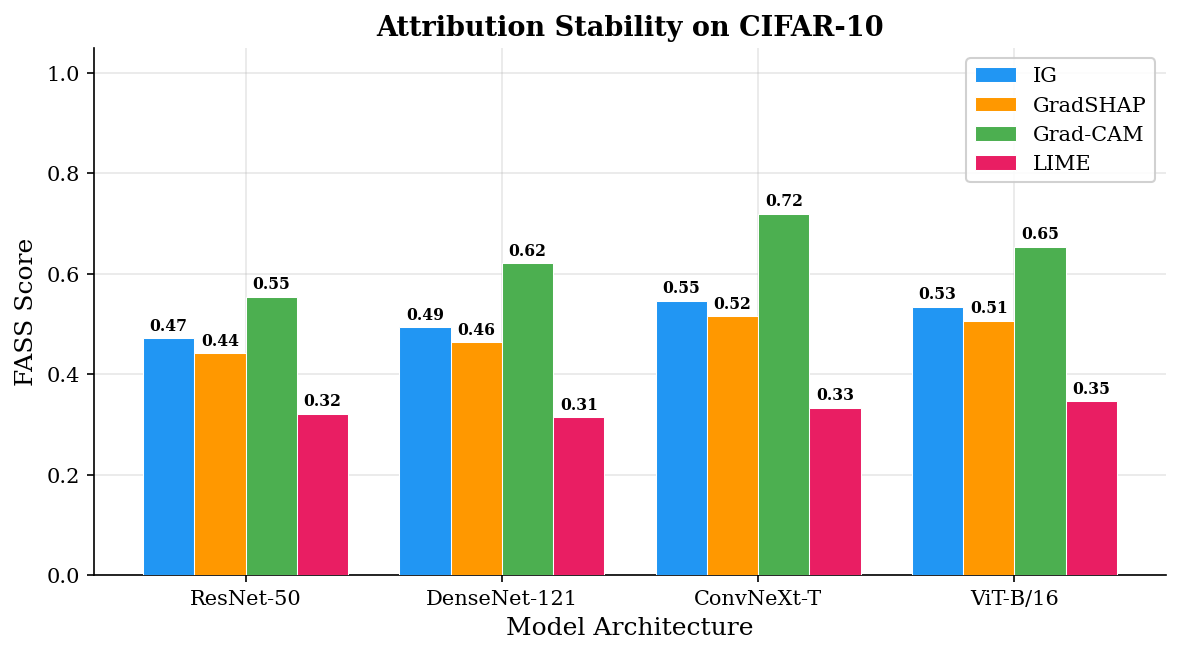

Saved: fass_bar_cifar10.pdf


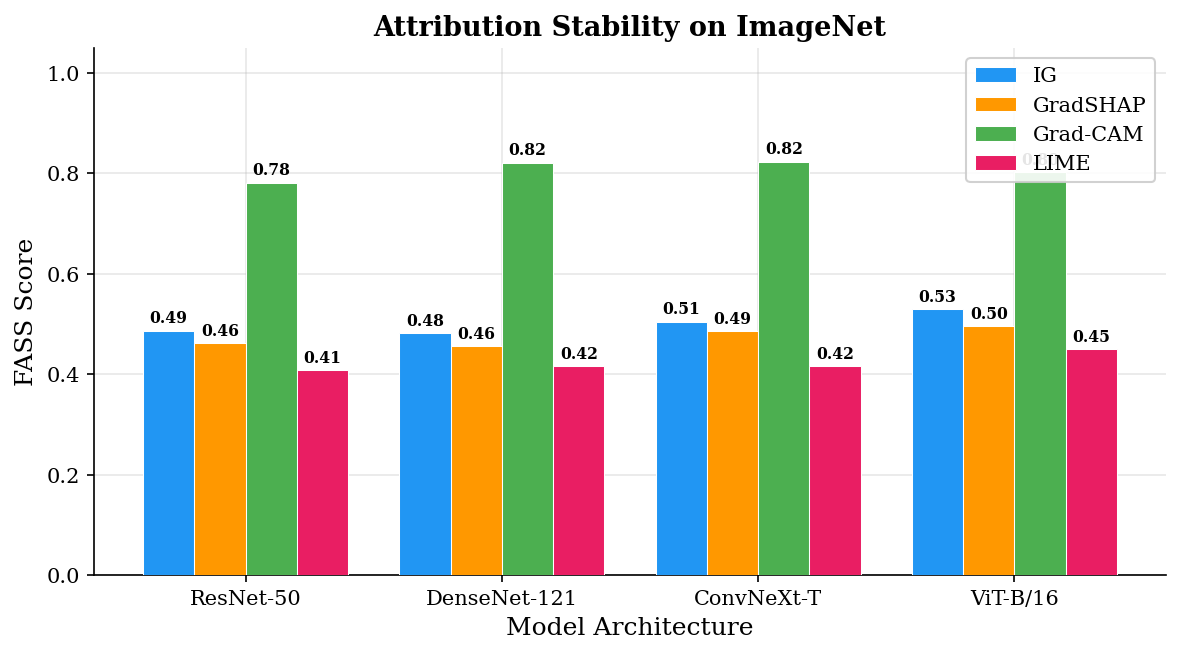

Saved: fass_bar_imagenet.pdf


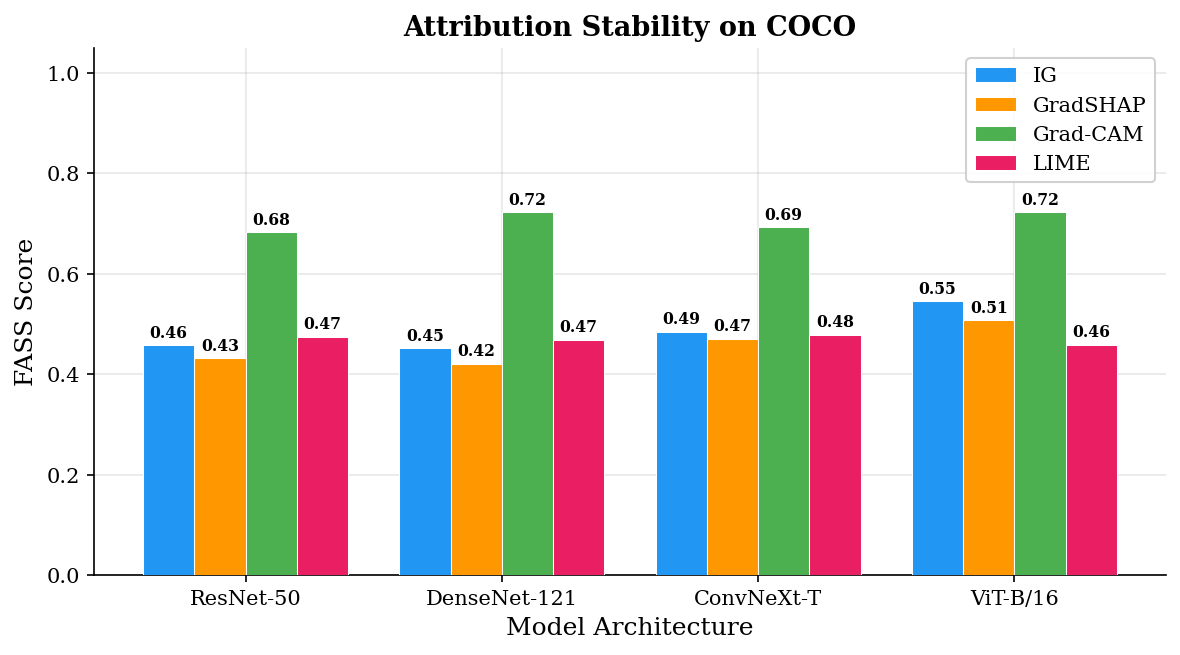

Saved: fass_bar_coco.pdf


In [10]:
# Cell 9 — Figure 1: Per-Dataset Grouped Bar Charts (3 figures)
#
# One chart per dataset. Item (4) in the paper plan.

for ds in results['dataset'].unique():
    tbl = dataset_tables[ds]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    models = list(tbl.index)
    methods = list(tbl.columns)
    x = np.arange(len(models))
    n_methods = len(methods)
    width = 0.8 / n_methods

    for i, method in enumerate(methods):
        vals = tbl[method].values
        bars = ax.bar(x + i * width - (n_methods - 1) * width / 2,
                      vals, width,
                      label=method,
                      color=XAI_COLORS[method],
                      edgecolor='white',
                      linewidth=0.5,
                      zorder=3)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=7.5,
                        fontweight='bold')

    ax.set_xlabel('Model Architecture')
    ax.set_ylabel('FASS Score')
    ax.set_title(f'Attribution Stability on {ds}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, zorder=0)

    plt.tight_layout()
    fname = f'fass_bar_{ds.lower().replace("-", "")}.pdf'
    plt.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, fname.replace('.pdf', '.png')), bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

Cross-dataset average FASS:
             IG  GradSHAP  Grad-CAM   LIME
CIFAR-10  0.512     0.482     0.637  0.329
ImageNet  0.501     0.475     0.807  0.423
COCO      0.485     0.458     0.705  0.470



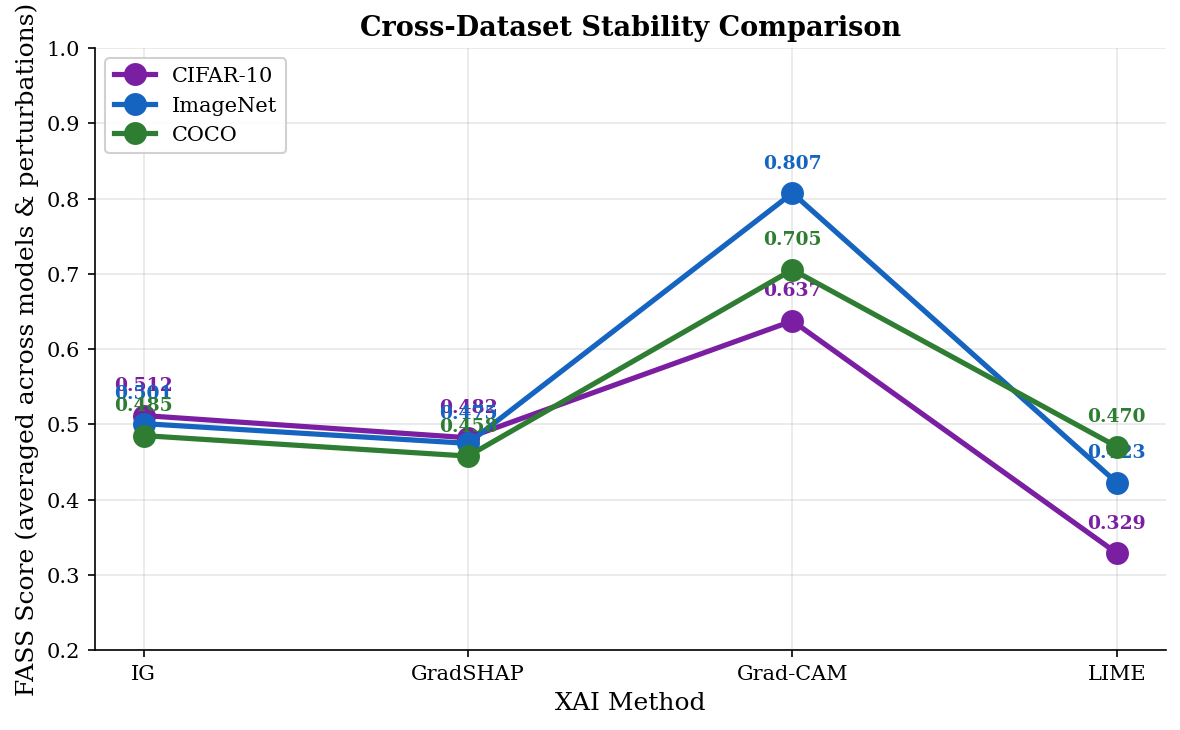


Most stable dataset:  ImageNet (0.551)
Least stable dataset: CIFAR-10 (0.490)
Saved: fass_cross_dataset.pdf


In [11]:
# Cell 10 — Figure 2: Cross-Dataset Comparison
#
# Line plot: X = XAI methods, Y = FASS, one line per dataset.
# Item (5) in the paper plan.

cross_data = {}
for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]
    method_avgs = {}
    for method in XAI_METHODS:
        vals = ds_df[method].dropna()
        if len(vals) > 0:
            method_avgs[XAI_DISPLAY[method]] = vals.mean()
    cross_data[ds] = method_avgs

cross_df = pd.DataFrame(cross_data).T

print('Cross-dataset average FASS:')
print(cross_df.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(8, 5))

methods_list = list(cross_df.columns)
x = np.arange(len(methods_list))

for ds in cross_df.index:
    vals = cross_df.loc[ds].values
    ax.plot(x, vals, 'o-', color=DATASET_COLORS.get(ds, '#333'),
            linewidth=2.5, markersize=10, label=ds, zorder=3)
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=9, fontweight='bold',
                        color=DATASET_COLORS.get(ds, '#333'))

ax.set_xlabel('XAI Method')
ax.set_ylabel('FASS Score (averaged across models & perturbations)')
ax.set_title('Cross-Dataset Stability Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods_list)
ax.set_ylim(0.2, 1.0)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fass_cross_dataset.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fass_cross_dataset.png'), bbox_inches='tight')
plt.show()

ds_grand = cross_df.mean(axis=1)
print(f'\nMost stable dataset:  {ds_grand.idxmax()} ({ds_grand.max():.3f})')
print(f'Least stable dataset: {ds_grand.idxmin()} ({ds_grand.min():.3f})')
print('Saved: fass_cross_dataset.pdf')

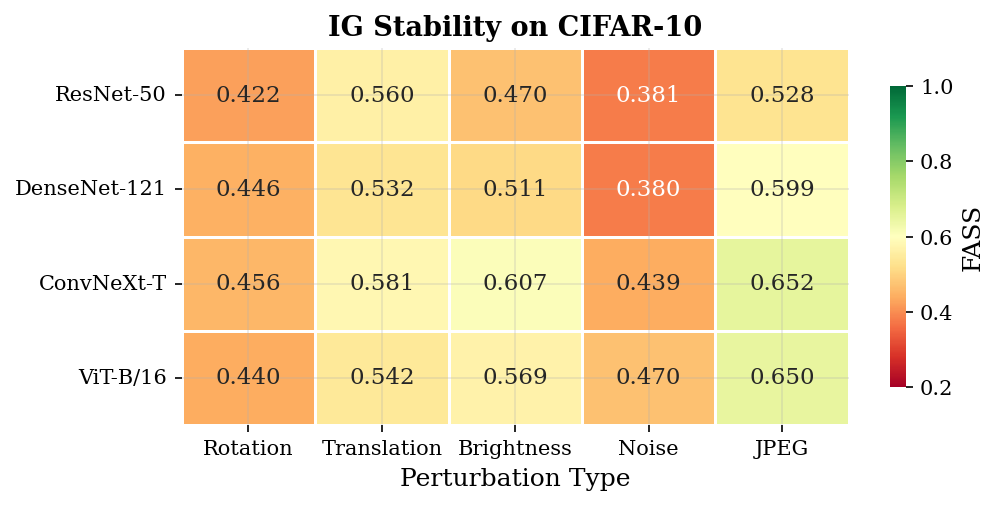

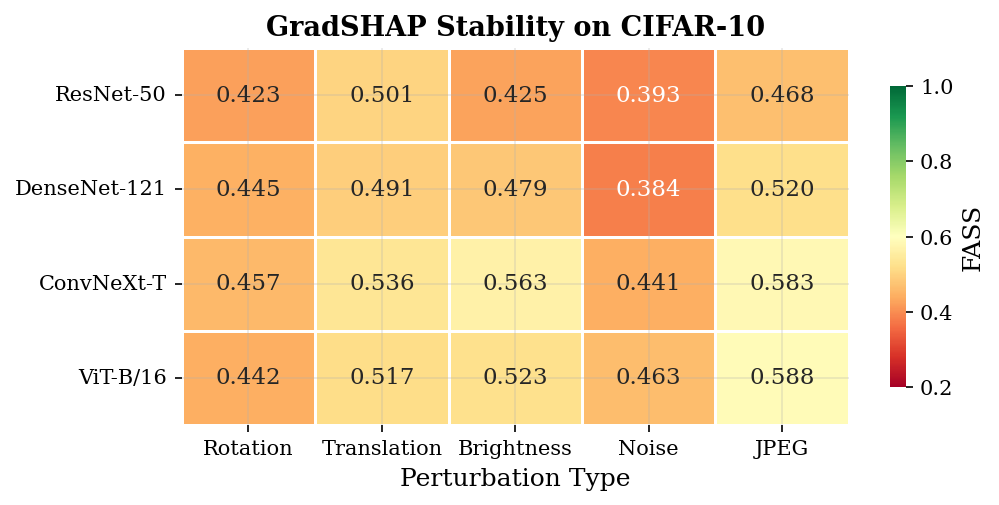

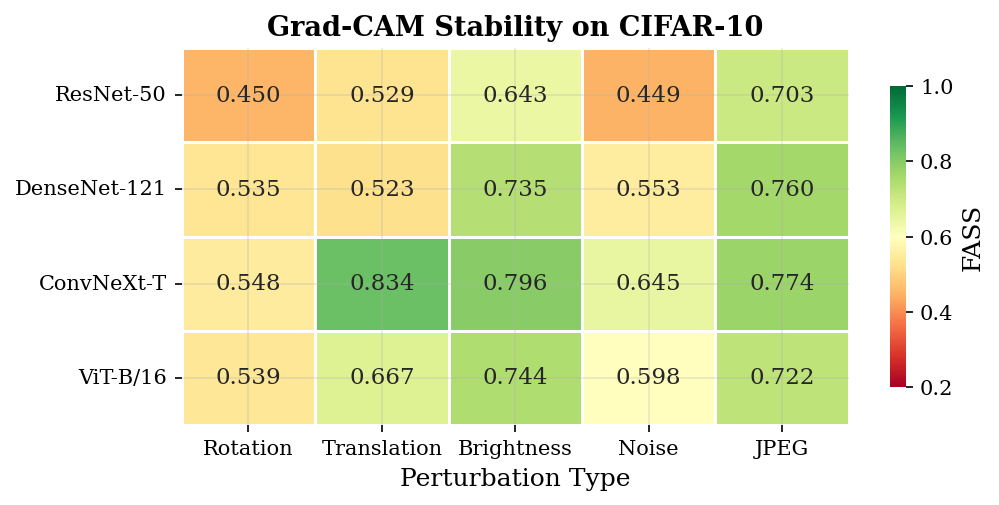

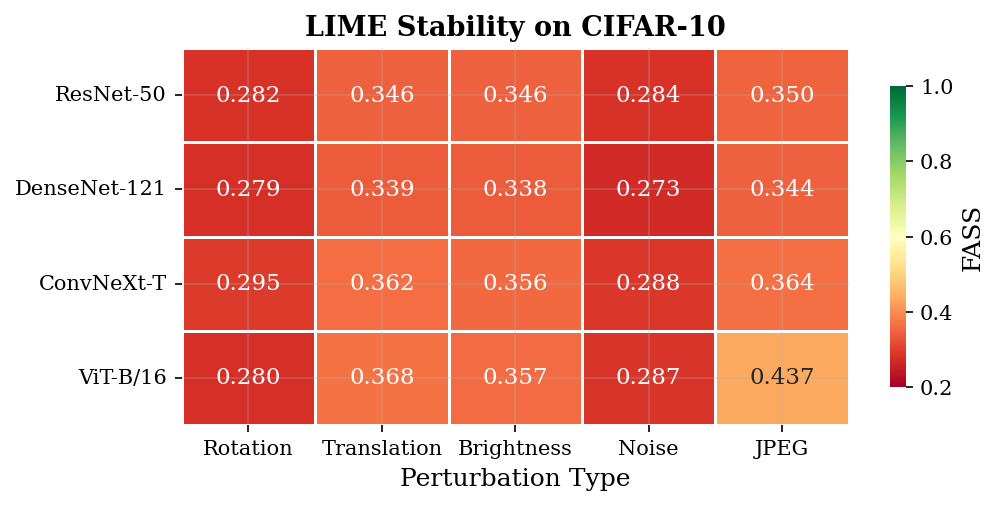

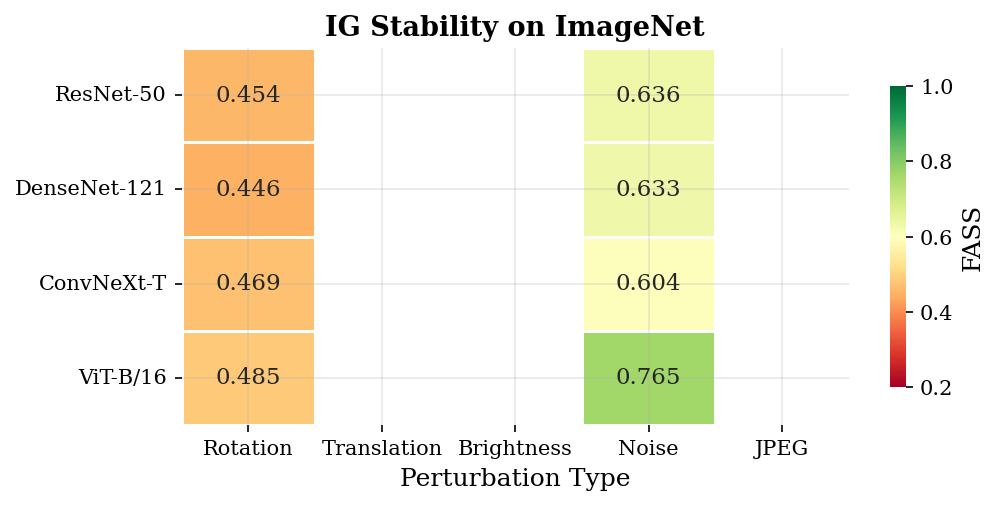

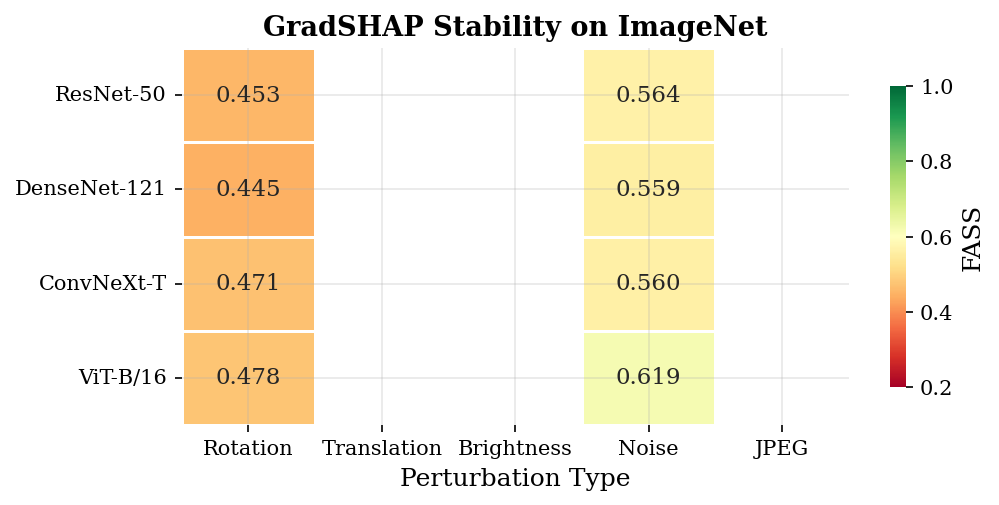

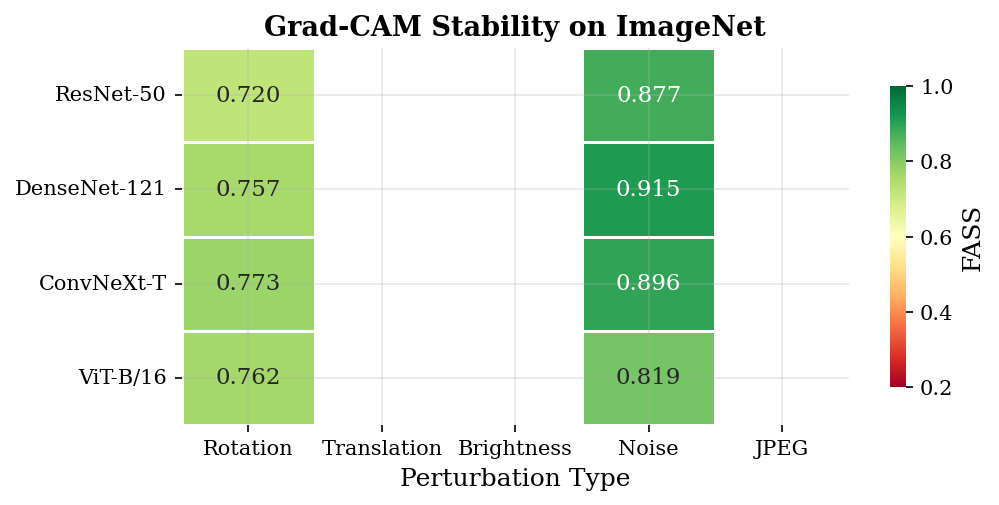

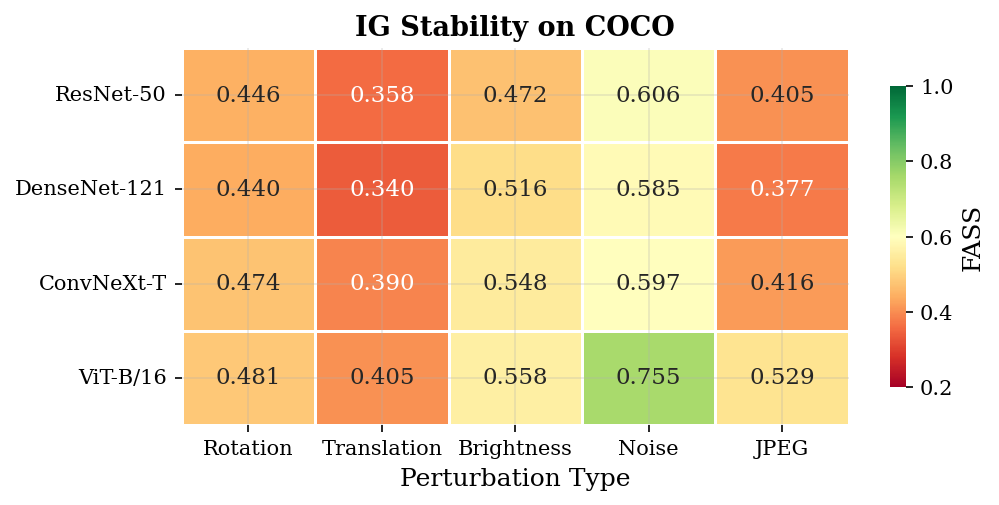

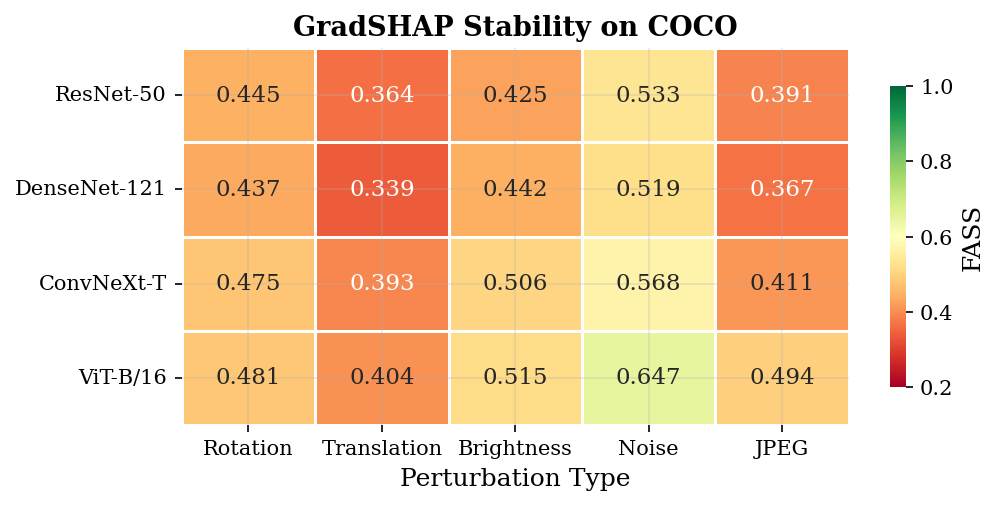

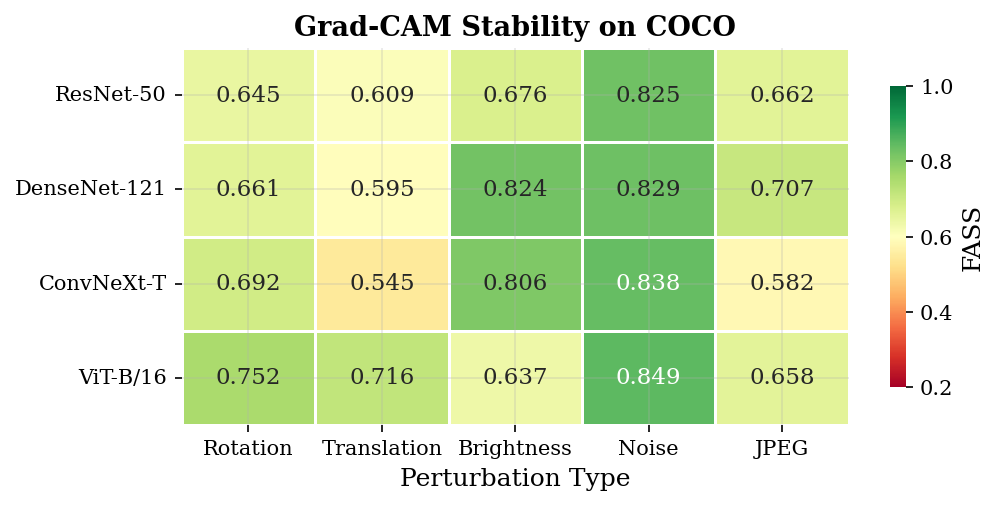

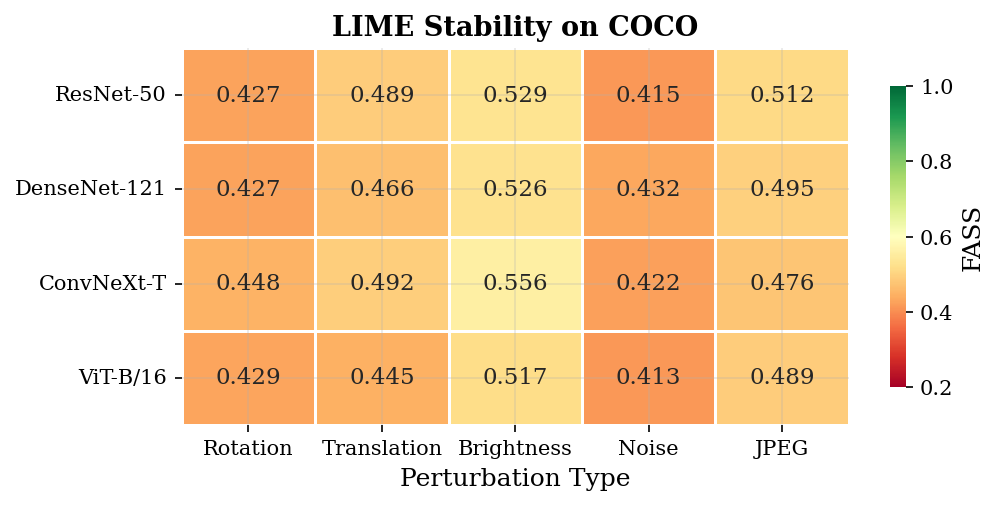

Appendix heatmaps saved.


In [12]:
# Cell 11 — Appendix: Per-Method Heatmaps (Model x Perturbation)

for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]

    for method in XAI_METHODS:
        method_name = XAI_DISPLAY[method]
        pivot = ds_df.pivot(index='model', columns='perturbation', values=method)
        pivot = pivot.reindex(index=MODEL_NAMES, columns=PERTURBATIONS)
        pivot.index = [MODEL_DISPLAY[m] for m in pivot.index]
        pivot.columns = [PERT_DISPLAY[p] for p in pivot.columns]

        if pivot.notna().sum().sum() == 0:
            continue

        fig, ax = plt.subplots(figsize=(7, 3.5))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=0.2, vmax=1.0, linewidths=0.5, ax=ax,
                    cbar_kws={'label': 'FASS', 'shrink': 0.8})
        ax.set_title(f'{method_name} Stability on {ds}', fontweight='bold')
        ax.set_ylabel('')
        ax.set_xlabel('Perturbation Type')
        plt.tight_layout()

        fname = f'heatmap_{ds.lower().replace("-", "")}_{method_name.lower().replace("-", "")}.pdf'
        plt.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show()

print('Appendix heatmaps saved.')

In [13]:
# Cell 12 — Grand Method Ranking

print('=' * 80)
print('GRAND METHOD RANKING')
print('=' * 80)

for method in XAI_METHODS:
    vals = results[method].dropna()
    if len(vals) > 0:
        print(f'  {XAI_DISPLAY[method]:>10s}: {vals.mean():.3f} +/- {vals.std():.3f}  '
              f'(n={len(vals)} conditions)')

print('\nRanking per dataset (most -> least stable):')
for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]
    method_means = {}
    for method in XAI_METHODS:
        vals = ds_df[method].dropna()
        if len(vals) > 0:
            method_means[XAI_DISPLAY[method]] = vals.mean()
    ranked = sorted(method_means.items(), key=lambda x: x[1], reverse=True)
    rank_str = ' > '.join([f'{k} ({v:.3f})' for k, v in ranked])
    print(f'  {ds}: {rank_str}')

global_means = {}
for method in XAI_METHODS:
    vals = results[method].dropna()
    if len(vals) > 0:
        global_means[XAI_DISPLAY[method]] = vals.mean()
ranked = sorted(global_means.items(), key=lambda x: x[1], reverse=True)
print(f'\n  GLOBAL: {" > ".join([f"{k} ({v:.3f})" for k, v in ranked])}')

print(f'\n--- Paper sentence ---')
print(f'Across all {results["dataset"].nunique()} datasets, {len(MODEL_NAMES)} architectures, '
      f'and {len(PERTURBATIONS)} perturbation types, '
      f'{ranked[0][0]} achieves the highest stability (FASS = {ranked[0][1]:.3f}), '
      f'followed by {ranked[1][0]} ({ranked[1][1]:.3f}), '
      f'{ranked[2][0]} ({ranked[2][1]:.3f}), and '
      f'{ranked[3][0]} ({ranked[3][1]:.3f}).')

GRAND METHOD RANKING
          IG: 0.509 +/- 0.099  (n=48 conditions)
    GradSHAP: 0.478 +/- 0.070  (n=48 conditions)
    Grad-CAM: 0.695 +/- 0.118  (n=48 conditions)
        LIME: 0.400 +/- 0.084  (n=40 conditions)

Ranking per dataset (most -> least stable):
  CIFAR-10: Grad-CAM (0.637) > IG (0.512) > GradSHAP (0.482) > LIME (0.329)
  ImageNet: Grad-CAM (0.815) > IG (0.561) > GradSHAP (0.519)
  COCO: Grad-CAM (0.705) > IG (0.485) > LIME (0.470) > GradSHAP (0.458)

  GLOBAL: Grad-CAM (0.695) > IG (0.509) > GradSHAP (0.478) > LIME (0.400)

--- Paper sentence ---
Across all 3 datasets, 4 architectures, and 5 perturbation types, Grad-CAM achieves the highest stability (FASS = 0.695), followed by IG (0.509), GradSHAP (0.478), and LIME (0.400).


In [14]:
# Cell 13 — Geometric vs Photometric Analysis

GEOMETRIC = ['rotation', 'translation']
PHOTOMETRIC = ['brightness', 'noise', 'jpeg']

print('=' * 80)
print('GEOMETRIC vs PHOTOMETRIC PERTURBATION ANALYSIS')
print('=' * 80)

for ds in results['dataset'].unique():
    ds_df = results[results['dataset'] == ds]
    print(f'\n--- {ds} ---')
    for method in XAI_METHODS:
        geo_vals = ds_df[ds_df['perturbation'].isin(GEOMETRIC)][method].dropna()
        photo_vals = ds_df[ds_df['perturbation'].isin(PHOTOMETRIC)][method].dropna()
        if len(geo_vals) > 0 and len(photo_vals) > 0:
            geo_mean = geo_vals.mean()
            photo_mean = photo_vals.mean()
            gap = photo_mean - geo_mean
            harder = 'geometric' if geo_mean < photo_mean else 'photometric'
            print(f'  {XAI_DISPLAY[method]:>10s}:  Geometric={geo_mean:.3f}  '
                  f'Photometric={photo_mean:.3f}  '
                  f'Gap={gap:+.3f} ({harder} harder)')

geo_all = results[results['perturbation'].isin(GEOMETRIC)][XAI_METHODS].mean().mean()
photo_all = results[results['perturbation'].isin(PHOTOMETRIC)][XAI_METHODS].mean().mean()
print(f'\nGLOBAL: Geometric={geo_all:.3f}, Photometric={photo_all:.3f}, '
      f'Gap={photo_all - geo_all:+.3f}')

GEOMETRIC vs PHOTOMETRIC PERTURBATION ANALYSIS

--- CIFAR-10 ---
          IG:  Geometric=0.497  Photometric=0.521  Gap=+0.024 (geometric harder)
    GradSHAP:  Geometric=0.476  Photometric=0.486  Gap=+0.009 (geometric harder)
    Grad-CAM:  Geometric=0.578  Photometric=0.677  Gap=+0.099 (geometric harder)
        LIME:  Geometric=0.319  Photometric=0.335  Gap=+0.017 (geometric harder)

--- ImageNet ---
          IG:  Geometric=0.463  Photometric=0.660  Gap=+0.196 (geometric harder)
    GradSHAP:  Geometric=0.462  Photometric=0.576  Gap=+0.114 (geometric harder)
    Grad-CAM:  Geometric=0.753  Photometric=0.877  Gap=+0.124 (geometric harder)

--- COCO ---
          IG:  Geometric=0.417  Photometric=0.530  Gap=+0.114 (geometric harder)
    GradSHAP:  Geometric=0.417  Photometric=0.485  Gap=+0.067 (geometric harder)
    Grad-CAM:  Geometric=0.652  Photometric=0.741  Gap=+0.089 (geometric harder)
        LIME:  Geometric=0.453  Photometric=0.482  Gap=+0.029 (geometric harder)

GLOBAL: Geo

In [15]:
# Cell 14 — Save master CSV

master_path = os.path.join(FIG_DIR, 'FASS_MASTER_RESULTS.csv')
results.to_csv(master_path, index=False)
print(f'Master results saved to: {master_path}')
print(f'Shape: {results.shape}')
print(f'Columns: {list(results.columns)}')

Master results saved to: /content/drive/MyDrive/xai-stability-benchmark/paper_figures/FASS_MASTER_RESULTS.csv
Shape: (60, 13)
Columns: ['dataset', 'model', 'perturbation', 'n_retained', 'retention_pct', 'ig_fass', 'ig_std', 'shap_fass', 'shap_std', 'gradcam_fass', 'gradcam_std', 'lime_fass', 'lime_std']


In [16]:
# Cell 15 — List all generated files

print('=' * 80)
print('GENERATED FILES')
print('=' * 80)

for f in sorted(os.listdir(FIG_DIR)):
    fpath = os.path.join(FIG_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {f:45s}  {size_kb:7.1f} KB')

GENERATED FILES
  FASS_MASTER_RESULTS.csv                            9.7 KB
  fass_bar_cifar10.pdf                              26.8 KB
  fass_bar_cifar10.png                             132.6 KB
  fass_bar_coco.pdf                                 26.7 KB
  fass_bar_coco.png                                127.1 KB
  fass_bar_imagenet.pdf                             27.4 KB
  fass_bar_imagenet.png                            120.7 KB
  fass_cross_dataset.pdf                            31.6 KB
  fass_cross_dataset.png                           246.6 KB
  heatmap_cifar10_gradcam.pdf                       28.0 KB
  heatmap_cifar10_gradshap.pdf                      28.2 KB
  heatmap_cifar10_ig.pdf                            27.0 KB
  heatmap_cifar10_lime.pdf                          27.2 KB
  heatmap_coco_gradcam.pdf                          27.0 KB
  heatmap_coco_gradshap.pdf                         27.1 KB
  heatmap_coco_ig.pdf                               25.9 KB
  heatmap_coco_lime.pdf 

In [17]:
import os, glob

path = '/content/drive/MyDrive/xai-stability-benchmark/results_imagenet'
files = sorted(glob.glob(os.path.join(path, '*.csv')))
print(f'{len(files)} files found:\n')
for f in files:
    print(f'  {os.path.basename(f)}')

20 files found:

  FINAL_FASS_IMAGENET_SUMMARY.csv
  convnext_tiny_fass_noise.csv
  convnext_tiny_fass_rotation.csv
  convnext_tiny_integrated_gradients.csv
  convnext_tiny_shap.csv
  densenet121_fass_noise.csv
  densenet121_fass_rotation.csv
  densenet121_gradcam.csv
  densenet121_integrated_gradients.csv
  densenet121_shap.csv
  resnet50_fass_noise.csv
  resnet50_fass_rotation.csv
  resnet50_gradcam.csv
  resnet50_integrated_gradients.csv
  resnet50_lime.csv
  resnet50_shap.csv
  vit_b_16_fass_noise.csv
  vit_b_16_fass_rotation.csv
  vit_b_16_integrated_gradients.csv
  vit_b_16_shap.csv


In [19]:
import pandas as pd
import os

path = '/content/drive/MyDrive/xai-stability-benchmark/results_imagenet'

for fname in sorted(os.listdir(path)):
    if not fname.endswith('.csv'):
        continue
    fpath = f'{path}/{fname}'
    size = os.path.getsize(fpath)
    if size < 100:
        print(f'{fname:50s}  {size:>8} bytes  ** EMPTY **')
        continue
    try:
        df = pd.read_csv(fpath)
        print(f'{fname:50s}  {size:>8} bytes  rows={len(df):>6}  cols={list(df.columns)}')
    except:
        print(f'{fname:50s}  {size:>8} bytes  ** READ ERROR **')

FINAL_FASS_IMAGENET_SUMMARY.csv                         1218 bytes  rows=     8  cols=['model', 'perturbation', 'n_images', 'ig_fass', 'shap_fass', 'gradcam_fass', 'ig_std', 'shap_std', 'gradcam_std']
convnext_tiny_fass_noise.csv                         1777955 bytes  rows= 28515  cols=['image_index', 'ig_fass', 'shap_fass', 'gradcam_fass']
convnext_tiny_fass_rotation.csv                      1726264 bytes  rows= 27316  cols=['image_index', 'ig_fass', 'shap_fass', 'gradcam_fass']
convnext_tiny_integrated_gradients.csv                168902 bytes  rows= 30000  cols=['image_index']
convnext_tiny_shap.csv                                168902 bytes  rows= 30000  cols=['image_index']
densenet121_fass_noise.csv                           1755768 bytes  rows= 28152  cols=['image_index', 'ig_fass', 'shap_fass', 'gradcam_fass']
densenet121_fass_rotation.csv                        1478480 bytes  rows= 23372  cols=['image_index', 'ig_fass', 'shap_fass', 'gradcam_fass']
densenet121_gradcam.csv    